
=== Running NSGA-II with seed 1 ===
Survival counts by operator: {np.str_('blend_crossover_batch'): np.int64(59), np.str_('parent'): np.int64(41)}
Gen 1: hypervolume=0.0000, igd=1.9688, gd=2.5247, gd_plus=2.5247, igd_plus=1.9687, spacing=0.1169, pbsr=0.5900, reward=1.0000, ql_alpha=1.0000, ql_state=1.0000, ql_action=2.0000, generation=1.0000, generation_time=0.0046, pair_cnt=100.0000, offspring_evals=100.0000
Survival counts by operator: {np.str_('blend_crossover_batch'): np.int64(60), np.str_('parent'): np.int64(40)}
Gen 2: hypervolume=0.0000, igd=1.9300, gd=2.2003, gd_plus=2.2003, igd_plus=1.9300, spacing=0.1370, pbsr=0.6000, reward=1.0000, ql_alpha=0.9955, ql_state=2.0000, ql_action=2.0000, generation=2.0000, generation_time=0.0039, pair_cnt=100.0000, offspring_evals=100.0000
Survival counts by operator: {np.str_('blend_crossover_batch'): np.int64(59), np.str_('parent'): np.int64(41)}
Gen 3: hypervolume=0.0000, igd=1.9198, gd=2.0471, gd_plus=2.0471, igd_plus=1.9198, spacing=0.1473,

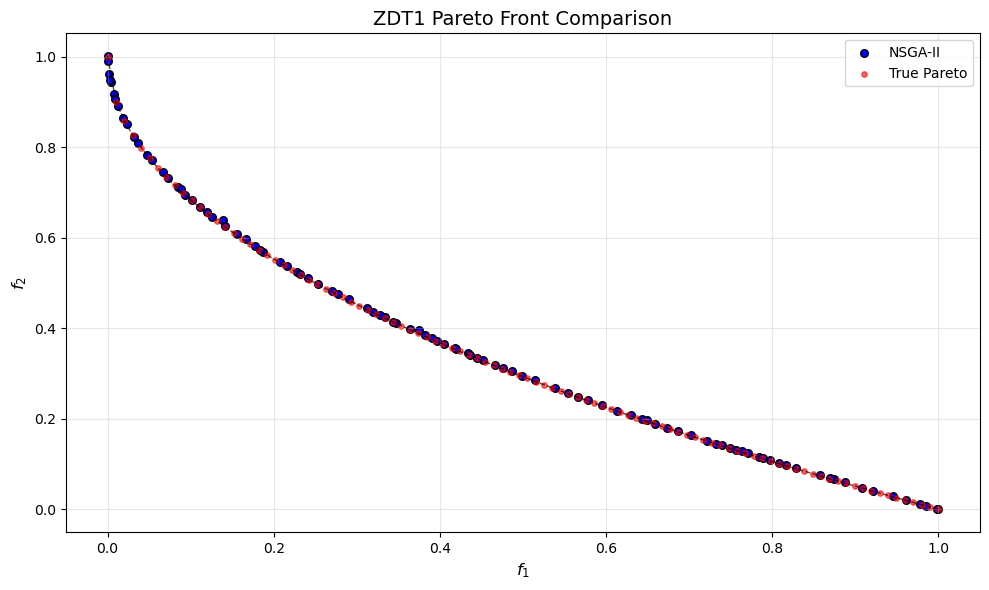

In [1]:

#### Cell 0: Imports and Setup

# 1. Problem Selection and Configuration
#According to Table 2 in the Parallel Variation Operator Strategy: Equal‑Budget Parallel Crossover Ensembles for NSGA‑II
problem_name = "zdt1"
n_var = 30  # Custom number of decision variables 
n_obj = 2  # Custom number of objectives

# 2. Population Settings
# -----------------------
pop_size = 100
generations = 200

# 3. Operator-specific parameters
#According to Table 1 in the Parallel Variation Operator Strategy: Equal‑Budget Parallel Crossover Ensembles for NSGA‑II
crossover_probability = 0.9
mutation_sigma = 0.5           
distribution_index_n_c = 15    # For simulated binary crossover
distribution_index_n_m = 20    # For polynomial mutation
blend_alpha = 0.5              # for blend crossover
swap_prob = 0.5                # For uniform crossover 


# 4. Select Crossover and Mutation Operators
# List all desired crossover operators to be applied in parallel.
selected_crossover_operator_names = [
    "simulated_binary_crossover_batch",
    "single_point_crossover_batch",
    "blend_crossover_batch",
    "uniform_crossover_batch"
    
]

selected_mutation_operator_name = "polynomial_mutation_batch"




# Cell 1:


import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
from IPython.display import display, clear_output
import time  
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
import random
from pymoo.problems import get_problem
from pymoo.operators.crossover.sbx import SBX
# --- Additional Metrics Imports (if not already imported) ---
from pymoo.indicators.gd import GD
from pymoo.indicators.gd_plus import GDPlus
from pymoo.indicators.igd_plus import IGDPlus
from pymoo.indicators.spacing import SpacingIndicator as Spacing
%matplotlib inline
plt.ion()  

# benchmarks.py
from pymoo.problems import get_problem as _get_problem

def _family(name: str) -> str:
    n = name.lower()
    if n.startswith("zdt"): return "zdt"
    if n.startswith("wfg"): return "wfg"
    if n.startswith("dtlz"): return "dtlz"
    if n.startswith("c") and "dtlz" in n: return "cdtlz"  # e.g. c1dtlz1
    return "unknown"

def get_problem_dynamic(name: str, n_var: int | None = None, n_obj: int | None = None):
    """
    Robustly instantiate a Pymoo problem without you having to remember the exact signature.
    Tries the 'right' order per family, then falls back gracefully.
    """
    fam = _family(name)

    # preferred try-orders per family
    if fam in {"dtlz", "wfg"}:
        attempts = [
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]
    elif fam == "zdt":
        attempts = [
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]
    elif fam == "cdtlz":
        attempts = [
            lambda: _get_problem(name),  # many constrained DTLZ variants expose fixed dims
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
        ]
    else:
        attempts = [
            lambda: _get_problem(name, n_var=n_var, n_obj=n_obj),
            lambda: _get_problem(name, n_var=n_var),
            lambda: _get_problem(name),
        ]

    last_err = None
    for a in attempts:
        try:
            return a()
        except TypeError as e:    # signature mismatch
            last_err = e
        except Exception as e:    # other errors (invalid name, etc.)
            last_err = e

    raise RuntimeError(
        f"Could not instantiate '{name}' with n_var={n_var}, n_obj={n_obj}. Last error: {last_err}"
    )







# Cell 2: Configuration Parameters

# =============================================================================
#                            PVOS-4C Configuration
# =============================================================================



problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)


D = problem.n_var        
M = problem.n_obj        
min_values = problem.xl  
max_values = problem.xu  
mutation_probability = 1/D 







# --- Dictionary Mapping for Metrics ---
metrics_dict = {
    "hv": lambda front, ref_point: HV(ref_point=ref_point).do(front) if ref_point is not None else None,
    "igd": lambda front, true_front: IGD(true_front).do(front),
    "gd": lambda front, true_front: GD(true_front).do(front),
    "gd_plus": lambda front, true_front: GDPlus(true_front).do(front),
    "igd_plus": lambda front, true_front: IGDPlus(true_front).do(front),
    "spacing": lambda front: np.nan if front.shape[0] < 2 else Spacing().do(front)

}



#  Random Seed for Reproducibility
# -----------------------------------
random_seed = 1 


#  Visualization Settings
# --------------------------
plot_interval = 1
display_intermediate = False


#  Metrics Computation Control
compute_metrics_each_gen = True    # Set True to compute metrics every generation
default_metrics_interval = 1    # Interval to use if not computing each generation




# main.ipynb - Cell 3
import numpy as np


def initial_population(population_size, min_values, max_values, problem):
    # Generate random decision variables within bounds
    rand_matrix = np.random.rand(population_size, problem.n_var)
    decision_vars = min_values + rand_matrix * (max_values - min_values)
    
    if hasattr(problem, 'n_constr') and problem.n_constr > 0:
        # Evaluate and get both objectives and constraints
        eval_result = problem.evaluate(decision_vars, return_values_of=['F', 'G'])
        F = eval_result[0]
        G = eval_result[1]
        # Compute aggregated constraint violation (CV) for each individual
        CV = np.sum(np.maximum(G, 0), axis=1, keepdims=True)
        if F.ndim == 3 and F.shape[1] == 1:
            F = np.squeeze(F, axis=1)
        return np.hstack([decision_vars, F, CV])
    else:
        eval_result = problem.evaluate(decision_vars)
        if isinstance(eval_result, tuple):
            F = eval_result[0]
        else:
            F = eval_result
        if F.ndim == 3 and F.shape[1] == 1:
            F = np.squeeze(F, axis=1)
        return np.hstack([decision_vars, F])






def fast_non_dominated_sort(population, num_objectives, num_constraints=0):


    
    population_size = population.shape[0]
    if num_constraints > 0:
        # Determine the starting index of objectives (exclude decision variables and constraint column)
        D = population.shape[1] - num_objectives - num_constraints
        F = population[:, D:D+num_objectives]
        cv = population[:, -num_constraints].flatten()  # aggregated constraint violation
        feasible = (cv == 0)
        
        # Pairwise objective comparisons (for feasible solutions)
        ObjA = F[:, None, :]  # shape (n, 1, M)
        ObjB = F[None, :, :]   # shape (1, n, M)
        dom_obj = (ObjA <= ObjB).all(axis=2) & (ObjA < ObjB).any(axis=2)
        
        # For infeasible solutions, compare only based on constraint violation
        cv_i = cv[:, None]
        cv_j = cv[None, :]
        dom_cv = cv_i < cv_j
        
        # Overall dominance: a feasible solution always dominates an infeasible one.
        # If both are feasible, use objective dominance.
        # If both are infeasible, the one with lower CV is better.
        dominates = ((feasible[:, None] & ~feasible[None, :]) |
                     (feasible[:, None] & feasible[None, :] & dom_obj) |
                     ((~feasible[:, None]) & (~feasible[None, :]) & dom_cv))
    else:
        F = population[:, -num_objectives:]
        ObjA = F[:, None, :]
        ObjB = F[None, :, :]
        dominates = (ObjA <= ObjB).all(axis=2) & (ObjA < ObjB).any(axis=2)
    

    adjacency = dominates
    n_dominate = adjacency.sum(axis=0)

    # Initialize rank assignments
    rank = np.full(population_size, -1, dtype=int)
    current_front = np.where(n_dominate == 0)[0]
    rank_level = 1

    # Identify subsequent Pareto fronts
    while len(current_front) > 0:
        rank[current_front] = rank_level
        dominated_any = adjacency[current_front, :].any(axis=0)
        
        counts = adjacency[current_front, :][:, dominated_any].sum(axis=0)
        n_dominate[dominated_any] -= counts

        newly_zero = (n_dominate == 0) & (rank == -1)
        current_front = np.where(newly_zero)[0]
        rank_level += 1

    return rank


def crowding_distance(population, num_objectives, front_indices, F_start):

    """
    Compute the crowding distance for the sub-population specified by 'front_indices'.
    """
    # Initialize crowding distance array for entire population
    cd = np.zeros(population.shape[0])
    
    # Handle boundary conditions: empty front or very small front
    if len(front_indices) == 0:
        return cd
    if len(front_indices) <= 2:
        cd[front_indices] = np.inf
        return cd

    # Extract objectives for the current front
    objectives = population[front_indices, F_start: F_start + num_objectives]

    num_individuals = len(front_indices)
    cd_local = np.zeros(num_individuals)

    # Calculate crowding distance for each objective
    for m in range(num_objectives):
        # Sort indices based on objective m
        sorted_idx_local = np.argsort(objectives[:, m])
        sorted_vals = objectives[sorted_idx_local, m]

        # Assign infinity to boundary points
        cd_local[sorted_idx_local[0]] = np.inf
        cd_local[sorted_idx_local[-1]] = np.inf

        # Normalize distance between neighboring individuals
        denom = sorted_vals[-1] - sorted_vals[0]
        if denom == 0:
            continue

        for i in range(1, num_individuals - 1):
            cd_local[sorted_idx_local[i]] += (sorted_vals[i+1] - sorted_vals[i-1]) / denom

    # Update the crowding distance for individuals in the current front
    cd[front_indices] = cd_local
    return cd


def compare_individuals(rank1, rank2, cd1, cd2):
    """
    Compare two individuals based on Pareto rank and crowding distance.
    """
    # Return True if first individual is better than second based on rank, 
    # or same rank but higher crowding distance.
    return (rank1 < rank2) | ((rank1 == rank2) & (cd1 > cd2))


def select_parents_batch(population, rank, cd, population_size):
    """
    Perform binary tournament selection in a vectorized manner to select parents.
    """
    total_individuals = population.shape[0]
    
    # First set of parents selection
    idx = np.random.randint(0, total_individuals, size=(population_size, 2))
    better = compare_individuals(rank[idx[:, 0]], rank[idx[:, 1]], cd[idx[:, 0]], cd[idx[:, 1]])
    parent1_idx = idx[:, 0]
    parent2_idx = idx[:, 1]
    selected_parents1 = np.where(better, parent1_idx, parent2_idx)

    # Second set of parents selection
    idx = np.random.randint(0, total_individuals, size=(population_size, 2))
    better = compare_individuals(rank[idx[:, 0]], rank[idx[:, 1]], cd[idx[:, 0]], cd[idx[:, 1]])
    parent1_idx = idx[:, 0]
    parent2_idx = idx[:, 1]
    selected_parents2 = np.where(better, parent1_idx, parent2_idx)

    return selected_parents1, selected_parents2

#cell 4




import numpy as np

def _sbx_core_batch(parents_dec_1, parents_dec_2, xl, xu,
                    eta_arr, prob_var_arr, prob_bin_arr,
                    eps=1e-14):
    """
    Core SBX operator matching pymoo.cross_sbx, but using
    parents_dec_1, parents_dec_2 instead of X.

    parents_dec_1, parents_dec_2 : (N, D)
    eta_arr, prob_var_arr, prob_bin_arr : (N, 1)

    Returns:
        Q : (2, N, D)  # two children per mating
    """
    parents_dec_1 = np.asarray(parents_dec_1, dtype=float)
    parents_dec_2 = np.asarray(parents_dec_2, dtype=float)
    xl = np.asarray(xl, dtype=float)
    xu = np.asarray(xu, dtype=float)

    N, D = parents_dec_1.shape
    X = np.stack([parents_dec_1, parents_dec_2], axis=0)  # (2, N, D)

    # probability of crossover for each variable
    prob_var_2d = np.repeat(prob_var_arr, D, axis=1)      # (N, D)
    cross = np.random.rand(N, D) < prob_var_2d

    # when solutions are too close -> do not apply sbx crossover
    too_close = np.abs(X[0] - X[1]) <= eps
    cross[too_close] = False

    # disable crossover when lower and upper bound are identical
    cross[:, xl == xu] = False

    # if no variable crosses at all, just clamp bounds and return
    if not np.any(cross):
        Q = X.copy()
        Q[0] = np.clip(Q[0], xl, xu)
        Q[1] = np.clip(Q[1], xl, xu)
        return Q

    # flatten the crossed positions
    p1 = X[0][cross]  # (n_cross,)
    p2 = X[1][cross]

    # orientation: y1 = smaller, y2 = larger
    sm = p1 < p2
    y1 = np.where(sm, p1, p2)
    y2 = np.where(sm, p2, p1)

    # bounds repeated and masked
    _xl = np.repeat(xl[None, :], N, axis=0)[cross]
    _xu = np.repeat(xu[None, :], N, axis=0)[cross]

    # eta, prob_bin expanded to (N, D) then masked
    eta_flat = np.repeat(eta_arr, D, axis=1)[cross]       # (n_cross,)
    prob_bin_flat = np.repeat(prob_bin_arr, D, axis=1)[cross]

    # shared random for both c1 and c2 (same as pymoo)
    rand = np.random.rand(len(eta_flat))

    def calc_betaq(beta):
        alpha = 2.0 - np.power(beta, -(eta_flat + 1.0))
        mask = rand <= (1.0 / alpha)
        mask_not = ~mask

        betaq = np.zeros_like(beta)
        if np.any(mask):
            betaq[mask] = np.power(rand[mask] * alpha[mask],
                                   1.0 / (eta_flat[mask] + 1.0))
        if np.any(mask_not):
            betaq[mask_not] = np.power(
                1.0 / (2.0 - rand[mask_not] * alpha[mask_not]),
                1.0 / (eta_flat[mask_not] + 1.0)
            )
        return betaq

    # difference between parents
    delta = (y2 - y1)

    # c1
    beta = 1.0 + (2.0 * (y1 - _xl) / delta)
    betaq = calc_betaq(beta)
    c1 = 0.5 * ((y1 + y2) - betaq * delta)

    # c2
    beta = 1.0 + (2.0 * (_xu - y2) / delta)
    betaq = calc_betaq(beta)
    c2 = 0.5 * ((y1 + y2) + betaq * delta)

    # children based on parent orientation
    child1 = np.where(sm, c1, c2)  # child aligned with parent 1
    child2 = np.where(sm, c2, c1)  # child aligned with parent 2

    # exchange children with probability prob_bin_flat and orientation
    b = np.bitwise_xor(
        np.random.rand(len(prob_bin_flat)) < prob_bin_flat,
        X[0][cross] > X[1][cross]
    )
    child1_final = np.where(b, child2, child1)
    child2_final = np.where(b, child1, child2)

    # assemble Q
    Q = X.copy()
    Q[0][cross] = child1_final
    Q[1][cross] = child2_final

    # clamp to bounds
    Q[0] = np.clip(Q[0], xl, xu)
    Q[1] = np.clip(Q[1], xl, xu)
    return Q


def simulated_binary_crossover_batch(parents_dec_1, parents_dec_2,
                                     prob, eta, min_values, max_values,
                                     n_offsprings=1,
                                     prob_exch=1.0,
                                     prob_bin=0.5,
                                     eps=1e-14):
    """
    Simulated Binary Crossover (SBX) matching pymoo.SBX(prob=..., eta=..., n_offsprings=...)

    Parameters
    ----------
    parents_dec_1 : (N, D)
    parents_dec_2 : (N, D)
    prob          : float
        Per-variable crossover probability (SBX 'prob' / 'prob_var').
    eta           : float
        Distribution index.
    min_values    : (D,)  lower bounds (xl)
    max_values    : (D,)  upper bounds (xu)
    n_offsprings  : 1 or 2
    prob_exch     : float, default 1.0
        Exchange probability (SBX prob_exch).
    prob_bin      : float, default 0.5
        Per-gene child swap probability (SBX prob_bin).
    eps           : float
        Threshold for "too close" parents.

    Returns
    -------
    offspring_dec :
        if n_offsprings == 1 : shape (N, D)
        if n_offsprings == 2 : shape (2*N, D)  [first N rows child1, next N rows child2]
    """
    parents_dec_1 = np.asarray(parents_dec_1, dtype=float)
    parents_dec_2 = np.asarray(parents_dec_2, dtype=float)
    min_values = np.asarray(min_values, dtype=float)
    max_values = np.asarray(max_values, dtype=float)

    N, D = parents_dec_1.shape

    # parameter arrays (N, 1) – same idea as pymoo's get(...)
    eta_arr = np.full((N, 1), eta, dtype=float)
    prob_var_arr = np.full((N, 1), prob, dtype=float)
    prob_exch_arr = np.full((N, 1), prob_exch, dtype=float)
    prob_bin_arr = np.full((N, 1), prob_bin, dtype=float)

    # apply prob_exch: zero out prob_bin if no exchange for that mating
    rand = np.random.rand(N, 1)
    prob_bin_arr[rand > prob_exch_arr] = 0.0

    # core SBX – returns two children per mating: Q shape (2, N, D)
    Q = _sbx_core_batch(parents_dec_1, parents_dec_2,
                        min_values, max_values,
                        eta_arr, prob_var_arr, prob_bin_arr,
                        eps=eps)

    if n_offsprings == 1:
        # randomly pick one of the two offspring per mating (same as SBX.n_offsprings=2)
        child = Q[0].copy()           # (N, D)
        pick_second = np.random.rand(N) < 0.5
        child[pick_second] = Q[1, pick_second]
        return child

    elif n_offsprings == 2:
        # stack to (2*N, D): [child1_0..child1_{N-1}, child2_0..child2_{N-1}]
        return Q.reshape(2 * N, D)

    else:
        raise ValueError("n_offsprings must be 1 or 2")





def single_point_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability, min_values, max_values):
    """
    Perform single-point crossover on a batch of parent pairs.

    Parameters:
        parents_dec_1 (np.ndarray): Decision variables of parent 1, shape (N, D).
        parents_dec_2 (np.ndarray): Decision variables of parent 2, shape (N, D).
        crossover_probability (float): Probability of performing crossover on a parent pair.
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).

    Returns:
        
    """

    num_offspring, num_decision_variables = parents_dec_1.shape

    # Start with child1 as a copy of parent 1
    child1 = parents_dec_1.copy()

    # Decide which pairs will undergo crossover
    crossover_mask = np.random.rand(num_offspring) < crossover_probability

    # --- NEW: handle no-crossover pairs without bias ---
    no_cross_indices = np.where(~crossover_mask)[0]
    if no_cross_indices.size > 0:
        # For each no-crossover pair, flip a coin: 0 -> keep parent 1, 1 -> copy parent 2
        use_parent2 = np.random.rand(no_cross_indices.size) < 0.5
        idx_parent2 = no_cross_indices[use_parent2]
        # Overwrite those children with parent 2
        child1[idx_parent2, :] = parents_dec_2[idx_parent2, :]

    # --- Existing crossover logic for the pairs that do crossover ---
    crossover_indices = np.where(crossover_mask)[0]
    if crossover_indices.size > 0:
        # One crossover point per selected pair
        crossover_points = np.random.randint(1, num_decision_variables, size=crossover_indices.size)

        for idx, cp in zip(crossover_indices, crossover_points):
            # NEW: randomly choose orientation to remove positional bias
            if np.random.rand() < 0.5:
                # suffix from parent2
                child1[idx, cp:] = parents_dec_2[idx, cp:]
            else:
                # prefix from parent2
                child1[idx, :cp] = parents_dec_2[idx, :cp]

    # Clip to bounds and return
    child1 = np.clip(child1, min_values, max_values)
    return child1




import numpy as np

def blend_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability, alpha_blend, min_values, max_values):

    N, D = parents_dec_1.shape

    child1 = parents_dec_1.copy()

    do_cross = np.random.rand(N) < crossover_probability

    # Handle pairs that do NOT crossover without bias
    no_cross_idx = np.where(~do_cross)[0]
    if no_cross_idx.size > 0:
        use_parent2 = np.random.rand(no_cross_idx.size) < 0.5
        idx_parent2 = no_cross_idx[use_parent2]
        child1[idx_parent2, :] = parents_dec_2[idx_parent2, :]

    cross_idx = np.where(do_cross)[0]
    if cross_idx.size > 0:
        p1 = parents_dec_1[cross_idx, :]
        p2 = parents_dec_2[cross_idx, :]

        y1 = np.minimum(p1, p2)
        y2 = np.maximum(p1, p2)
        d = y2 - y1

        # Full extended range — NO clamping to bounds here
        lower_bound = y1 - alpha_blend * d
        upper_bound = y2 + alpha_blend * d

        # Sample uniformly in the extended range
        rand1 = np.random.rand(p1.shape[0], D)
        c1 = lower_bound + rand1 * (upper_bound - lower_bound)

        child1[cross_idx, :] = c1

    # Clip AFTER sampling — this creates the boundary bias that helps ZDT convergence
    child1 = np.clip(child1, min_values, max_values)
    return child1


import numpy as np

def uniform_crossover_batch(parents_dec_1, parents_dec_2, crossover_probability,  min_values, max_values, swap_prob=swap_prob):
    """
    Perform Uniform Crossover on a batch of parent pairs.

    Parameters:
        parents_dec_1 (np.ndarray): Decision variables of parent 1, shape (N, D).
        parents_dec_2 (np.ndarray): Decision variables of parent 2, shape (N, D).
        crossover_probability (float): Probability of performing crossover on each parent pair.
        swap_prob (float, optional): Probability of swapping each gene. Defaults to 0.5.
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).

    Returns:
        tuple: Two arrays containing offspring decision variables, each of shape (N, D).
    """
    # Determine the number of parent pairs (N) and number of decision variables (D).
    N, D = parents_dec_1.shape
    p_c = crossover_probability

    # Initialize offspring arrays as copies of the parent decision variables.
    child1 = parents_dec_1.copy()
    

    # Determine which parent pairs will undergo crossover based on probability.
    do_cross = np.random.rand(N) < p_c

    # Handle pairs that do NOT crossover without bias:
    # for those indices, randomly choose between parent 1 and parent 2.
    no_cross_indices = np.where(~do_cross)[0]
    if no_cross_indices.size > 0:
        # Flip a coin for each no-crossover pair:
        # True -> use parent 2, False -> keep parent 1.
        use_parent2 = np.random.rand(no_cross_indices.size) < 0.5
        idx_parent2 = no_cross_indices[use_parent2]
        child1[idx_parent2, :] = parents_dec_2[idx_parent2, :]

    # If no pairs are selected for crossover, we are done.
    if not np.any(do_cross):
        child1 = np.clip(child1, min_values, max_values)
        return child1

    # Extract the parent pairs selected for crossover.
    p1 = parents_dec_1[do_cross, :]
    p2 = parents_dec_2[do_cross, :]

    # Generate a mask for each gene indicating whether to swap based on swap_prob.
    swap_mask = np.random.rand(p1.shape[0], D) < swap_prob

    # Create copies to hold the offspring genes.
    offspring1 = p1.copy()

    # Perform the swap where the mask is True.
    offspring1[swap_mask] = p2[swap_mask]

    # Assign the offspring genes back to the full child array.
    child1[do_cross, :] = offspring1

    # Ensure offspring values are within the specified bounds.
    child1 = np.clip(child1, min_values, max_values)

    # Return the generated offspring decision variables.
    return child1





def polynomial_mutation_batch(offspring_dec, mutation_probability, distribution_index_n_m,
                              min_values, max_values, at_least_once=False):
    """
    Perform Polynomial Mutation on a batch of offspring decision variables.

    This operator follows the conventional scheme (as in pymoo) and
    applies a mutation to each gene with a given probability.
    
    Parameters:
        offspring_dec (np.ndarray): Offspring decision variables, shape (N, D).
        mutation_probability (float): Mutation probability per gene.
        distribution_index_n_m (float): Mutation distribution index (η₍m₎).
        min_values (np.ndarray): Lower bounds for decision variables, shape (D,).
        max_values (np.ndarray): Upper bounds for decision variables, shape (D,).
        at_least_once (bool): If True, ensure that at least one gene per individual is mutated.
        
    Returns:
        np.ndarray: Mutated offspring decision variables, shape (N, D).
    """
    N, D = offspring_dec.shape
    p_m = mutation_probability
    eta_m = distribution_index_n_m

    # Create a gene-wise mutation mask.
    mutation_mask = np.random.rand(N, D) < p_m
    # Do not allow mutation where lower and upper bounds are identical.
    mutation_mask[:, (min_values == max_values)] = False

    # If at_least_once is True, force at least one mutation per individual (if possible).
    if at_least_once:
        for i in range(N):
            if not np.any(mutation_mask[i]):
                # Identify genes that are allowed to be mutated.
                allowed = np.where(min_values != max_values)[0]
                if allowed.size > 0:
                    j = np.random.choice(allowed)
                    mutation_mask[i, j] = True

    # Convert offspring_dec to float for mutation computations.
    x = offspring_dec.astype(float).copy()

    # Compute the range for each decision variable.
    range_ = max_values - min_values

    # Compute normalized distances to the bounds.
    delta1 = (x - min_values) / (range_ + 1e-14)
    delta2 = (max_values - x) / (range_ + 1e-14)

    # Generate random numbers for the mutation process.
    u = np.random.rand(N, D)

    # Initialize delta_q (the mutation step sizes).
    deltaq = np.zeros((N, D))

    # Mutation: apply the polynomial mutation formula only for genes marked for mutation.
    # Branch where u < 0.5:
    mask1 = mutation_mask & (u < 0.5)
    if np.any(mask1):
        tmp = 2 * u[mask1] + (1 - 2 * u[mask1]) * np.power(1 - delta1[mask1], (eta_m + 1))
        deltaq[mask1] = np.power(tmp, 1.0 / (eta_m + 1)) - 1.0

    # Branch where u >= 0.5:
    mask2 = mutation_mask & (u >= 0.5)
    if np.any(mask2):
        tmp = 2 * (1 - u[mask2]) + 2 * (u[mask2] - 0.5) * np.power(1 - delta2[mask2], (eta_m + 1))
        deltaq[mask2] = 1.0 - np.power(tmp, 1.0 / (eta_m + 1))

    # Apply the mutation step.
    x = x + deltaq * range_
    # Ensure the mutated values are within the bounds.
    x = np.clip(x, min_values, max_values)

    return x


def gaussian_mutation_batch(offspring_dec, mutation_probability, sigma, min_values, max_values):
    """
    Perform Gaussian mutation on a batch of offspring decision variables.
    """
    # Determine population size and number of decision variables
    num_offspring, num_decision_variables = offspring_dec.shape
    
    # Create a mutation mask for each decision variable of each offspring
    mutation_mask = np.random.rand(num_offspring, num_decision_variables) < mutation_probability
    # Generate Gaussian noise where mutation is to be applied
    noise = np.random.normal(0, sigma, (num_offspring, num_decision_variables)) * mutation_mask
    # Apply mutation
    offspring_dec = offspring_dec + noise
    
    # Ensure mutated offspring values are within bounds
    offspring_dec = np.clip(offspring_dec, min_values, max_values)
    return offspring_dec



# Cell 5: Complete PVOS-4C Implementation with Pymoo Benchmarks
from joblib import Parallel, delayed
from pymoo.core.population import Population
from pymoo.core.individual import Individual

class _ArrayProblem:
    """Minimal stub so SBX sees n_var, xl, xu."""
    def __init__(self, xl, xu):
        self.xl, self.xu = xl, xu
        self.n_var = len(xl)
def run_nsga2(problem, population_size, generations,
             crossover_probability, mutation_probability,
             selected_crossover_operator_names,
             selected_mutation_operator_name,
             distribution_index_n_c, distribution_index_n_m,
             blend_alpha, swap_prob, mutation_sigma,
             random_seed, plot_interval, display_intermediate,
             metrics_interval, record_history=False):
    
    # Get problem parameters from Pymoo object
    num_objectives = problem.n_obj
    num_decision_variables = problem.n_var
    min_values = problem.xl
    max_values = problem.xu
    num_constraints = 1 if (hasattr(problem, 'n_constr') and problem.n_constr > 0) else 0
    # objective slice in your population array [X | F] (or [X | F | CV])
    F_start = num_decision_variables
    F_end   = num_decision_variables + num_objectives

    def _eval_F_and_CV(X):
        """Evaluate F (and CV if you use it) with the same shape handling you already do."""
        if hasattr(problem, 'n_constr') and problem.n_constr > 0:
            F, G = problem.evaluate(X, return_values_of=['F', 'G'])
            CV = np.sum(np.maximum(G, 0), axis=1, keepdims=True)
            if F.ndim == 3 and F.shape[1] == 1:
                F = np.squeeze(F, axis=1)
            return F, CV
        else:
            eval_result = problem.evaluate(X)
            F = eval_result[0] if isinstance(eval_result, tuple) else eval_result
            if F.ndim == 3 and F.shape[1] == 1:
                F = np.squeeze(F, axis=1)
            return F, None
    # Initialize operator map
    operator_map = {
        "simulated_binary_crossover_batch": simulated_binary_crossover_batch,
        "single_point_crossover_batch": single_point_crossover_batch,
        "polynomial_mutation_batch": polynomial_mutation_batch,
        "gaussian_mutation_batch": gaussian_mutation_batch,
        "blend_crossover_batch": blend_crossover_batch,
        "uniform_crossover_batch": uniform_crossover_batch
    }

    # Convert crossover operator names to function objects
    crossover_ops = [operator_map[co_name] for co_name in selected_crossover_operator_names]
    # Get mutation operator
    selected_mutation_operator = operator_map[selected_mutation_operator_name]

    # Set random seeds
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Initialize population
    population = initial_population(population_size, min_values, max_values, problem)
    # --- Q-learning controller for crossover selection ---
    # State/action indices follow the current order in selected_crossover_operator_names.
    if len(crossover_ops) != 4:
        raise ValueError("This Q-learning baseline expects exactly 4 crossover operators.")

    q_table = np.zeros((4, 4), dtype=float)   # rows = states, cols = actions
    gamma_q = 0.6                             # paper: discount factor gamma = 0.6
    prev_pbsr = 0.0                           # paper: P0 = 0

    def greedy_action_with_random_tie_break(q_row):
        best = np.flatnonzero(q_row == np.max(q_row))
        return np.random.choice(best)

    # paper: randomly select an initial state, then choose the best action for that state
    current_state = np.random.randint(4)
    current_action = greedy_action_with_random_tie_break(q_table[current_state])
    metrics_history = []
    front_history = []
    true_pf_history = []
    gen_history = []
    
    true_pf_static = problem.pareto_front() if hasattr(problem, "pareto_front") else None
    

    # Helper function for parallel variation
    def apply_crossover_and_mutation(co, parents_dec_1, parents_dec_2, selected_mutation_operator,
                                     mutation_probability, distribution_index_n_c, distribution_index_n_m,
                                     mutation_sigma, blend_alpha, swap_prob, min_values, max_values, 
                                     crossover_probability):
        # Apply the specified crossover operator, each crossover produced one child.
        if co == simulated_binary_crossover_batch:
            sbx = SBX(prob=crossover_probability,
                      eta=distribution_index_n_c,
                      n_offsprings=1)
        
            _prob = _ArrayProblem(min_values, max_values)
        
            matings = [[Individual(X=p1), Individual(X=p2)]
                       for p1, p2 in zip(parents_dec_1, parents_dec_2)]
        
            # single call → (N, D) offspring
            child_dec = sbx.do(_prob, matings).get("X")      
               


        elif co == single_point_crossover_batch:
            
            child_dec= single_point_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                min_values,
                max_values
            )
        elif co == blend_crossover_batch:
            child_dec = blend_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                blend_alpha,
                min_values,
                max_values
            )
        elif co == uniform_crossover_batch:
            child_dec = uniform_crossover_batch(
                parents_dec_1,
                parents_dec_2,
                crossover_probability,
                min_values,
                max_values,
                swap_prob
            )
  

        else:
            raise ValueError("Crossover operator not recognized.")
    
        # Apply the selected mutation operator on the offspring
        if selected_mutation_operator == polynomial_mutation_batch:
            child_dec = polynomial_mutation_batch(
                child_dec,
                mutation_probability,
                distribution_index_n_m,
                min_values,
                max_values
            )

        elif selected_mutation_operator == gaussian_mutation_batch:
            child_dec = gaussian_mutation_batch(
                child_dec,
                mutation_probability,
                mutation_sigma,
                min_values,
                max_values
            )

        else:
            raise ValueError("Selected mutation operator not recognized.")
    
        # Evaluate offspring
        offspring_dec = child_dec                         
        
        if hasattr(problem, 'n_constr') and problem.n_constr > 0:
            F, G = problem.evaluate(offspring_dec, return_values_of=['F', 'G'])
            CV   = np.sum(np.maximum(G, 0), axis=1, keepdims=True)
            if F.ndim == 3 and F.shape[1] == 1:
                F = np.squeeze(F, axis=1)
            offspring = np.hstack([offspring_dec, F, CV])
        else:
            eval_result = problem.evaluate(offspring_dec)
            F = eval_result[0] if isinstance(eval_result, tuple) else eval_result
            if F.ndim == 3 and F.shape[1] == 1:
                F = np.squeeze(F, axis=1)
            offspring = np.hstack([offspring_dec, F])
        
        return {"offspring": offspring, "operator": co.__name__}



    # Main evolutionary loop
    for generation in range(1, generations + 1):
        gen_start = time.time()
        
        # Non-dominated sorting
        rank = fast_non_dominated_sort(population, num_objectives, num_constraints)

        
        # Crowding distance calculation
        crowding = np.zeros(len(population))
        for r in range(1, rank.max()+1):
            front_idx = np.where(rank == r)[0]
            crowding += crowding_distance(population, num_objectives, front_idx, F_start)

        # --- Q-learning chooses ONE crossover operator for the whole generation ---
        state_t = current_state
        action_t = current_action
        selected_operator = crossover_ops[action_t]

        # one selected operator generates the full offspring population
        pair_cnt = population_size
        p1_idx, p2_idx = select_parents_batch(population, rank, crowding, pair_cnt)
        parents1 = population[p1_idx, :num_decision_variables]
        parents2 = population[p2_idx, :num_decision_variables]

        res = apply_crossover_and_mutation(
            selected_operator, parents1, parents2,
            selected_mutation_operator,
            mutation_probability,
            distribution_index_n_c,
            distribution_index_n_m,
            mutation_sigma,
            blend_alpha,
            swap_prob,
            min_values,
            max_values,
            crossover_probability
        )

        combined_offspring = res["offspring"]
        offspring_operator_ids = np.full(combined_offspring.shape[0], res["operator"])

        # tag parents vs offspring origin
        original_operator_ids = np.array(["parent"] * population.shape[0])
        combined_operator_ids = np.concatenate([original_operator_ids, offspring_operator_ids])

        # combine parents and offspring for NSGA-II environmental selection
        combined_pop = np.vstack([population, combined_offspring])

        rank_combined = fast_non_dominated_sort(combined_pop, num_objectives, num_constraints)

        crowding_combined = np.zeros(len(combined_pop))

        for r in range(1, rank_combined.max()+1):
            front_idx = np.where(rank_combined == r)[0]
            crowding_combined += crowding_distance(combined_pop, num_objectives, front_idx, F_start)


        # Environmental selection
        survivors = []
        current_rank = 1
        while len(survivors) < population_size and current_rank <= rank_combined.max():
            front_idx = np.where(rank_combined == current_rank)[0]
            if len(survivors) + len(front_idx) <= population_size:
                survivors.extend(front_idx)
            else:
                sorted_front = sorted([(i, crowding_combined[i]) for i in front_idx], 
                                    key=lambda x: -x[1])
                survivors.extend([i for i, _ in sorted_front[:population_size-len(survivors)]])
            current_rank += 1

        population = combined_pop[survivors]
        # Extract operator labels for the survivors
        surviving_operator_ids = combined_operator_ids[survivors]
        
        # Compute counts of survivors per operator
        unique, counts = np.unique(surviving_operator_ids, return_counts=True)
        survival_stats = dict(zip(unique, counts))
        print("Survival counts by operator:", survival_stats)
        # --- Q-learning update ---
        # Pbsr = |P ∩ Q| / |Q|, implemented as:
        # number of selected survivors that came from offspring / total offspring
        offspring_survivors = np.count_nonzero(surviving_operator_ids != "parent")
        pbsr = offspring_survivors / combined_offspring.shape[0]

        # reward from change in Pbsr
        reward = 1 if pbsr > prev_pbsr else -1

        # paper uses t starting at 0, so generation 1 corresponds to t = 0
        alpha_t = 1.0 - 0.9 * ((generation - 1) / generations)

        # state induced by the operator just used
        next_state = action_t

        # standard Q-learning update
        old_q = q_table[state_t, action_t]
        q_table[state_t, action_t] = (
            (1.0 - alpha_t) * old_q
            + alpha_t * (reward + gamma_q * np.max(q_table[next_state]))
        )

        prev_pbsr = pbsr
        current_state = next_state
        current_action = greedy_action_with_random_tie_break(q_table[current_state])
        # Identify the non-dominated front in the new population
        non_dominated_indices = [i for i in survivors if rank_combined[i] == 1]
        non_dominated_front = combined_pop[non_dominated_indices, problem.n_var: problem.n_var + num_objectives]
        if record_history:
            front_history.append(non_dominated_front.copy())
            true_pf_history.append(true_pf_static.copy() if true_pf_static is not None else None)
            gen_history.append(generation)

        gen_time = time.time() - gen_start

        # Metrics calculation
        if metrics_interval and generation % metrics_interval == 0:
            current_front = non_dominated_front
            
            # Reference point handling
            
            if num_objectives in [2, 3]:
                true_pareto_front = problem.pareto_front() if hasattr(problem, "pareto_front") else None
                if true_pareto_front is not None:
                    nadir_point = np.max(true_pareto_front, axis=0)
                    ref_point = nadir_point * 1.1
                else:
                    ref_point = None  # or define a default reference point, e.g., np.array([1.0, 1.0])


            else:
                ref_point = None

                
            # Metric calculations
            # Compute metrics using the mapping defined in Cell 2
            # Dictionary to hold computed metrics for this generation
            metrics_results = {}
            
            for metric_name, metric_func in metrics_dict.items():
                if metric_name == "hv":
                    metrics_results["hypervolume"] = metric_func(current_front, ref_point)
                elif metric_name in ["igd", "gd", "gd_plus", "igd_plus"]:
                    metrics_results[metric_name] = metric_func(current_front, true_pareto_front) if true_pareto_front is not None else None
                elif metric_name == "spacing":
                    metrics_results["spacing"] = metric_func(current_front)
                else:
                    # If you add other metrics with different signatures, adjust here.
                    metrics_results[metric_name] = metric_func(current_front)
            
            # Add generation and generation time to the metrics record
            metrics_results["crossover_survival"] = survival_stats
            metrics_results["selected_operator"] = res["operator"]
            metrics_results["pbsr"] = pbsr
            metrics_results["reward"] = reward
            metrics_results["ql_alpha"] = alpha_t
            metrics_results["ql_state"] = int(state_t)
            metrics_results["ql_action"] = int(action_t)
            metrics_results["generation"] = generation
            metrics_results["generation_time"] = gen_time
            metrics_results["pair_cnt"] = pair_cnt
            #metrics_results["pm_used"] = [mut_prob_eff] * len(crossover_ops)
            #metrics_results["eta_m_used"] = [eta_m_eff] * len(crossover_ops)

            # how many offspring were evaluated this generation
            metrics_results["offspring_evals"] = combined_offspring.shape[0]

            # evaluations used for change detection sampling each gen
            #metrics_results["sample_evals"] = n_samples

            # evaluations used when you re-evaluate the whole population after a change
           # metrics_results["parent_reeval_evals"] = population_size if change_detected else 0

            #metrics_results["total_evals_this_gen"] = (
            #    combined_offspring.shape[0] 
            #)
            # ----------------------------------------------------------------------            
            # Append to the overall metrics history
            metrics_history.append(metrics_results)
            
            # Optionally print computed metrics for this generation
            print("Gen {}: {}".format(
                generation,
                ", ".join([f"{k}={v:.4f}" for k, v in metrics_results.items() if isinstance(v, (int, float))])
            ))
        # Visualization
        if display_intermediate and (generation % plot_interval == 0):
            current_front = non_dominated_front
            true_pf = problem.pareto_front() if hasattr(problem, 'pareto_front') else None
            
            plt.figure(figsize=(8, 6))
            if num_objectives == 2:
                plt.scatter(current_front[:, 0], current_front[:, 1], c='blue', label='Approximated')
                if true_pf is not None:
                    plt.scatter(true_pf[:, 0], true_pf[:, 1], c='red', alpha=0.5, label='True')
                plt.xlabel("f1"), plt.ylabel("f2")
            elif num_objectives == 3:
                ax = plt.axes(projection='3d')
                ax.scatter3D(current_front[:, 0], current_front[:, 1], current_front[:, 2], c='blue')
                if true_pf is not None:
                    ax.scatter3D(true_pf[:, 0], true_pf[:, 1], true_pf[:, 2], c='red', alpha=0.5)
                ax.set_xlabel("f1"), ax.set_ylabel("f2"), ax.set_zlabel("f3")
            
            plt.title(f"{problem.__class__.__name__} Generation {generation}")
            plt.legend()
            plt.show()
            clear_output(wait=True)

    history = None
    if record_history:
        history = {
            "front": front_history,
            "true_pf": true_pf_history,
            "generation": gen_history
        }
    
    return population, problem.pareto_front(), metrics_history, history




#cell6
def plot_pareto_front(approximated_front, true_front, problem):
    """
    Plot comparison between approximated and true Pareto fronts (using Pymoo data for the analytical solution)
    
    """
    plt.figure(figsize=(10, 6))
    
    # Get problem metadata from Pymoo
    num_objectives = problem.n_obj
    problem_name = problem.__class__.__name__
    
    if num_objectives == 2:
        # 2D Plot for approximated front
        plt.scatter(approximated_front[:, 0], approximated_front[:, 1], 
                   c='blue', s=30, edgecolors='k', label='NSGA-II')
        
        # Plot true Pareto front only if available
        if true_front is not None:
            plt.scatter(true_front[:, 0], true_front[:, 1],
                        c='red', s=15, alpha=0.6, label='True Pareto')
        
        plt.xlabel("$f_1$", fontsize=12)
        plt.ylabel("$f_2$", fontsize=12)
        plt.title(f"{problem_name} Pareto Front Comparison", fontsize=14)
        
    elif num_objectives == 3:
        # 3D Plot for approximated front
        ax = plt.axes(projection='3d')
        ax.scatter3D(approximated_front[:, 0], approximated_front[:, 1], approximated_front[:, 2],
                     c='blue', s=30, edgecolors='k', label='NSGA-II')
        if true_front is not None:
            ax.scatter3D(true_front[:, 0], true_front[:, 1], true_front[:, 2],
                         c='red', s=15, alpha=0.6, label='True Pareto')
        
        ax.set_xlabel("$f_1$", fontsize=10)
        ax.set_ylabel("$f_2$", fontsize=10)
        ax.set_zlabel("$f_3$", fontsize=10)
        ax.view_init(elev=45, azim=45)
        plt.title(f"{problem_name} 3D Pareto Front", fontsize=14)
    else:
        print(f"Visualization not supported for {num_objectives} objectives")
        return

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # Optionally, if a true Pareto front is available and it is 2D, you can plot a continuous line.
    if true_front is not None and num_objectives == 2:
        plt.plot(true_front[:, 0], true_front[:, 1], 
                 c='black', lw=1, ls='--', alpha=0.7, label='Analytical Solution')
            
    plt.show()




# cell 7

import numpy as np
import importlib



# Determine the metrics interval based on the control flag.
metrics_interval_value = default_metrics_interval if compute_metrics_each_gen else None


# =============================================================================
#                         Modified Execution Function
# =============================================================================

def run_nsga2_for_seed(seed):
    """Run NSGA-II for a single seed with proper Pymoo integration"""
    print(f"\n=== Running NSGA-II with seed {seed} ===")
    
    
    
    problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)
    

    


    
    # 2. Run NSGA-II with corrected parameters
    final_population, true_pareto, metrics_history, history = run_nsga2(
        problem=problem,  
        population_size=pop_size,
        generations=generations,
        crossover_probability=crossover_probability,
        mutation_probability=mutation_probability,
        selected_crossover_operator_names=selected_crossover_operator_names,
        selected_mutation_operator_name=selected_mutation_operator_name,
        distribution_index_n_c=distribution_index_n_c,
        distribution_index_n_m=distribution_index_n_m,
        blend_alpha=blend_alpha,
        swap_prob=swap_prob,
        mutation_sigma=mutation_sigma,
        random_seed=seed,
        plot_interval=plot_interval,
        display_intermediate=display_intermediate,
        metrics_interval=metrics_interval_value
    )
    
    # 3. Add seed information to metrics
    for metric in metrics_history:
        metric['seed'] = seed

    # 4. Identify non-dominated solutions
    num_constraints = 1 if (hasattr(problem, 'n_constr') and problem.n_constr > 0) else 0
    final_rank = fast_non_dominated_sort(final_population, problem.n_obj, num_constraints)

    non_dominated_indices = np.where(final_rank == 1)[0]
    pareto_points = final_population[non_dominated_indices, D : D + M]
    
    # 5. Plot results if enabled
    if display_intermediate:
        plot_pareto_front(pareto_points, true_pareto, problem)
        
    return {
        'seed': seed,
        'final_population': final_population,
        'true_pareto': true_pareto,
        'metrics_history': metrics_history,
        'pareto_points': pareto_points,
        'history': history

    }

# Run NSGA-II in parallel for seeds 1 to 30 (or 31 if you prefer 1 to 31) in series 
seeds = range(1, 2)
results = Parallel(n_jobs=1)(delayed(run_nsga2_for_seed)(seed) for seed in seeds)

# Prepare containers for combined metrics and final populations.
all_metrics = []      
final_populations = []  
true_paretos = []       

# Process the results from parallel runs.
for result in results:
    seed = result['seed']
    final_populations.append(result['final_population'])
    true_paretos.append(result['true_pareto'])
    all_metrics.extend(result['metrics_history'])
    
    pareto_points = result['pareto_points']
    print(f"Seed {seed} - Number of Pareto front points: {pareto_points.shape[0]}")
    


    if pareto_points.size > 0:
        plot_pareto_front(
            approximated_front=pareto_points,
            true_front=result['true_pareto'],

            problem = get_problem_dynamic(problem_name, n_var=n_var, n_obj=n_obj)

        )
    else:
        print(f"Seed {seed}: Empty Pareto front")







    

    


### Cell 8: Save Combined Metrics History to Excel 
import pandas as pd
import re

# Convert the all_metrics list to DataFrame
df_metrics = pd.DataFrame(all_metrics)

# Sanitize problem name for filename
problem_name_clean = re.sub(r'[^a-zA-Z0-9_]', '', problem.__class__.__name__).lower()


# Define a mapping from the full crossover operator names to shortcuts
crossover_shortcuts = {
    "simulated_binary_crossover_batch": "sbx",
    "blend_crossover_batch": "blx",
    "single_point_crossover_batch": "spx",
    "uniform_crossover_batch": "ux"
}

# Convert selected crossover operator names to their shortcut representation
selected_crossover_shortcut_names = [
    crossover_shortcuts.get(name, name) for name in selected_crossover_operator_names
]

# Join the shortcuts into a single string (e.g., "sbx-blx")
crossover_str = "-".join(selected_crossover_shortcut_names)

# Create valid filename
excel_filename = (
    f"{problem_name_clean} {len(selected_crossover_operator_names)} {crossover_str} cross 1 poly "
    f"{pop_size}pop {generations}gen QL.xlsx"
)

#{crossover_str}

# Save to Excel
df_metrics.to_excel(excel_filename, index=False)
print(f"Metrics saved to '{excel_filename}'")

In [2]:
# =========================
# New Cell: Run all Table 2 problems exactly as manual — Q-learning variant
# =========================

import os
import re
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import Parallel, delayed

# Recompute so this cell is self-contained
metrics_interval_value = default_metrics_interval if compute_metrics_each_gen else None

# -------------------------------------------------
# 1) Table 2 benchmark list
# -------------------------------------------------
TABLE2_PROBLEMS = (
    [{"name": f"zdt{i}",   "n_var": 30, "n_obj": 2, "generations": 200}  for i in [1, 2, 3]] +
    [{"name": f"zdt{i}",   "n_var": 10, "n_obj": 2, "generations": 400}  for i in [4, 6]] +
    [{"name": f"dtlz{i}",  "n_var": 12, "n_obj": 3, "generations": 1000} for i in [1, 3]] +
    [{"name": f"dtlz{i}",  "n_var": 12, "n_obj": 3, "generations": 200}  for i in [2, 5, 7]] +
    [{"name": "dtlz4",     "n_var": 12, "n_obj": 3, "generations": 500}] +
    [{"name": "dtlz6",     "n_var": 12, "n_obj": 3, "generations": 1000}] +
    [{"name": f"wfg{i}",   "n_var": 6,  "n_obj": 3, "generations": 200}  for i in range(1, 10)] +
    [{"name": "c1dtlz1",   "n_var": 12, "n_obj": 3, "generations": 1000}] +
    [{"name": "c2dtlz2",   "n_var": 12, "n_obj": 3, "generations": 200}] +
    [{"name": "c3dtlz4",   "n_var": 7,  "n_obj": 3, "generations": 500}] +
    [{"name": "dc1dtlz1",  "n_var": 12, "n_obj": 3, "generations": 1000}] +
    [{"name": "dc1dtlz3",  "n_var": 12, "n_obj": 3, "generations": 1000}] +
    [{"name": "dc3dtlz1",  "n_var": 12, "n_obj": 3, "generations": 1000}]
)

SEEDS = range(1, 2)
OUTPUT_DIR = Path("QLearning results Time")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CROSSOVER_SHORTCUTS = {
    "simulated_binary_crossover_batch": "sbx",
    "blend_crossover_batch": "blx",
    "single_point_crossover_batch": "spx",
    "uniform_crossover_batch": "ux"
}
MUTATION_SHORTCUTS = {
    "polynomial_mutation_batch": "poly",
    "gaussian_mutation_batch": "gauss"
}


def build_excel_name(problem_name, generations):
    problem_name_clean = re.sub(r"[^a-zA-Z0-9_]", "", problem_name).lower()
    crossover_str = "-".join(
        CROSSOVER_SHORTCUTS.get(name, name)
        for name in selected_crossover_operator_names
    )
    mutation_str = MUTATION_SHORTCUTS.get(selected_mutation_operator_name, selected_mutation_operator_name)
    return (
        f"{problem_name_clean} {len(selected_crossover_operator_names)} {crossover_str} "
        f"cross 1 {mutation_str} {pop_size}pop {generations}gen QL.xlsx"
    )


def flatten_columns(columns):
    out = []
    for col in columns:
        if isinstance(col, tuple):
            out.append("_".join([str(x) for x in col if str(x) != ""]).rstrip("_"))
        else:
            out.append(str(col))
    return out


# -------------------------------------------------
# 2) Per-seed runner — identical to manual Cell 7
#    Uses the ORIGINAL get_problem_dynamic from Cell 1
#    NO make_problem_safe wrapper
#    Q-learning state (q_table, gamma, etc.) is all internal to run_nsga2
#    so no extra params needed — just the base signature
# -------------------------------------------------
def run_seed_manual(problem_cfg, seed):
    """
    Runs exactly like the manual code:
      - Uses get_problem_dynamic from Cell 1 (family-aware, no safety wrapper)
      - Calls run_nsga2 with the same arguments as Cell 7
      - Q-learning controller is initialized inside run_nsga2 automatically
      - Post-processes with fast_non_dominated_sort just like Cell 7
    """
    problem = get_problem_dynamic(
        problem_cfg["name"],
        n_var=problem_cfg["n_var"],
        n_obj=problem_cfg["n_obj"]
    )

    D_local = problem.n_var
    M_local = problem.n_obj
    mutation_probability_local = 1.0 / D_local

    print(f"\n=== Running NSGA-II (Q-learning) with seed {seed} ===")

    # Call run_nsga2 with the exact same signature as Cell 7
    # Q-learning state is fully internal to run_nsga2 (q_table, gamma_q, prev_pbsr)
    final_population, true_pareto, metrics_history, history = run_nsga2(
        problem=problem,
        population_size=pop_size,
        generations=problem_cfg["generations"],
        crossover_probability=crossover_probability,
        mutation_probability=mutation_probability_local,
        selected_crossover_operator_names=selected_crossover_operator_names,
        selected_mutation_operator_name=selected_mutation_operator_name,
        distribution_index_n_c=distribution_index_n_c,
        distribution_index_n_m=distribution_index_n_m,
        blend_alpha=blend_alpha,
        swap_prob=swap_prob,
        mutation_sigma=mutation_sigma,
        random_seed=seed,
        plot_interval=plot_interval,
        display_intermediate=False,
        metrics_interval=metrics_interval_value,
        record_history=False
    )

    # Add seed info to metrics — same as Cell 7
    for metric in metrics_history:
        metric["seed"] = seed

    # Identify non-dominated solutions — same as Cell 7
    num_constraints = 1 if (hasattr(problem, 'n_constr') and problem.n_constr > 0) else 0
    final_rank = fast_non_dominated_sort(final_population, problem.n_obj, num_constraints)
    non_dominated_indices = np.where(final_rank == 1)[0]
    pareto_points = final_population[non_dominated_indices, D_local:D_local + M_local]

    print(f"Seed {seed} - Number of Pareto front points: {pareto_points.shape[0]}")

    return {
        "seed": seed,
        "final_population": final_population,
        "true_pareto": true_pareto,
        "metrics_history": metrics_history,
        "pareto_points": pareto_points,
    }


# -------------------------------------------------
# 3) Run all problems, each with 30 seeds in parallel
# -------------------------------------------------
all_final_tables = []
failures = []

for idx, problem_cfg in enumerate(TABLE2_PROBLEMS, start=1):
    prob_name = problem_cfg["name"].upper()
    print(f"\n{'='*60}")
    print(f"[{idx}/{len(TABLE2_PROBLEMS)}] {prob_name} | "
          f"D={problem_cfg['n_var']}, M={problem_cfg['n_obj']}, G={problem_cfg['generations']}")
    print(f"{'='*60}")

    try:
        # Run 30 seeds in parallel — same as Cell 7 uses Parallel
        seed_results = Parallel(n_jobs=1)(
            delayed(run_seed_manual)(problem_cfg, seed) for seed in SEEDS
        )

        # Collect metrics and final rows — same post-processing as Cell 7
        all_metrics = []
        final_rows = []

        for result in seed_results:
            seed = result["seed"]
            all_metrics.extend(result["metrics_history"])

            # Build final row from last generation metrics
            final_row = {
                "problem": problem_cfg["name"],
                "seed": seed,
                "n_var": problem_cfg["n_var"],
                "n_obj": problem_cfg["n_obj"],
                "configured_generations": problem_cfg["generations"],
                "population_size": pop_size,
                "pareto_size": int(result["pareto_points"].shape[0]),
            }
            if result["metrics_history"]:
                final_row.update(result["metrics_history"][-1])
            final_rows.append(final_row)

        df_metrics = pd.DataFrame(all_metrics)
        df_final = pd.DataFrame(final_rows).sort_values("seed").reset_index(drop=True)

        if not df_metrics.empty:
            # Convert dict columns to strings for Excel compatibility
            for col in ["crossover_survival"]:
                if col in df_metrics.columns:
                    df_metrics[col] = df_metrics[col].astype(str)
            df_metrics = df_metrics.sort_values(["seed", "generation"]).reset_index(drop=True)

        # Summary stats
        numeric_cols = [
            c for c in [
                "hypervolume", "igd", "gd", "gd_plus", "igd_plus",
                "spacing", "generation_time", "offspring_evals", "pareto_size"
            ]
            if c in df_final.columns
        ]

        summary_rows = []
        for col in numeric_cols:
            s = pd.to_numeric(df_final[col], errors="coerce").dropna()
            if not s.empty:
                summary_rows.append({
                    "metric": col,
                    "mean": s.mean(),
                    "std": s.std(),
                    "min": s.min(),
                    "max": s.max()
                })
        df_summary = pd.DataFrame(summary_rows)

        # Save per-problem Excel
        excel_path = OUTPUT_DIR / build_excel_name(problem_cfg["name"], problem_cfg["generations"])
        with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
            df_metrics.to_excel(writer, sheet_name="all_metrics", index=False)
            df_final.to_excel(writer, sheet_name="final_gen_by_seed", index=False)
            df_summary.to_excel(writer, sheet_name="summary", index=False)

        print(f"Saved: {excel_path}")
        all_final_tables.append(df_final)

    except Exception as e:
        print(f"FAILED: {problem_cfg['name']} -> {e}")
        failures.append({
            "problem": problem_cfg["name"],
            "n_var": problem_cfg["n_var"],
            "n_obj": problem_cfg["n_obj"],
            "generations": problem_cfg["generations"],
            "error": str(e)
        })

# -------------------------------------------------
# 4) Master summary across all problems
# -------------------------------------------------
df_all_final = pd.concat(all_final_tables, ignore_index=True) if all_final_tables else pd.DataFrame()
df_failures = pd.DataFrame(failures)
df_problem_table = pd.DataFrame(TABLE2_PROBLEMS)

if not df_all_final.empty:
    metric_cols = [
        c for c in [
            "hypervolume", "igd", "gd", "gd_plus", "igd_plus",
            "spacing", "generation_time", "offspring_evals", "pareto_size"
        ]
        if c in df_all_final.columns
    ]
    if metric_cols:
        agg_dict = {col: ["mean", "std"] for col in metric_cols}
        df_problem_summary = (
            df_all_final
            .groupby(["problem", "n_var", "n_obj", "configured_generations"], dropna=False)
            .agg(agg_dict)
            .reset_index()
        )
        df_problem_summary.columns = flatten_columns(df_problem_summary.columns)
        df_problem_summary = df_problem_summary.sort_values("problem").reset_index(drop=True)
    else:
        df_problem_summary = pd.DataFrame()
else:
    df_problem_summary = pd.DataFrame()

summary_path = OUTPUT_DIR / "ALL_PROBLEMS_SUMMARY_QL.xlsx"
with pd.ExcelWriter(summary_path, engine="openpyxl") as writer:
    df_problem_table.to_excel(writer, sheet_name="benchmark_table", index=False)
    df_all_final.to_excel(writer, sheet_name="final_gen_all_seeds", index=False)
    df_problem_summary.to_excel(writer, sheet_name="problem_summary", index=False)
    df_failures.to_excel(writer, sheet_name="failures", index=False)

print(f"\nMaster summary saved: {summary_path}")
if failures:
    print(f"\n{len(failures)} problem(s) failed:")
    for f in failures:
        print(f"  {f['problem']}: {f['error']}")

df_problem_summary


[1/27] ZDT1 | D=30, M=2, G=200

=== Running NSGA-II (Q-learning) with seed 1 ===
Survival counts by operator: {np.str_('blend_crossover_batch'): np.int64(59), np.str_('parent'): np.int64(41)}
Gen 1: hypervolume=0.0000, igd=1.9688, gd=2.5247, gd_plus=2.5247, igd_plus=1.9687, spacing=0.1169, pbsr=0.5900, reward=1.0000, ql_alpha=1.0000, ql_state=1.0000, ql_action=2.0000, generation=1.0000, generation_time=0.0071, pair_cnt=100.0000, offspring_evals=100.0000
Survival counts by operator: {np.str_('blend_crossover_batch'): np.int64(60), np.str_('parent'): np.int64(40)}
Gen 2: hypervolume=0.0000, igd=1.9300, gd=2.2003, gd_plus=2.2003, igd_plus=1.9300, spacing=0.1370, pbsr=0.6000, reward=1.0000, ql_alpha=0.9955, ql_state=2.0000, ql_action=2.0000, generation=2.0000, generation_time=0.0042, pair_cnt=100.0000, offspring_evals=100.0000
Survival counts by operator: {np.str_('blend_crossover_batch'): np.int64(59), np.str_('parent'): np.int64(41)}
Gen 3: hypervolume=0.0000, igd=1.9198, gd=2.0471, gd_

,problem,n_var,n_obj,configured_generations,hypervolume_mean,hypervolume_std,igd_mean,igd_std,gd_mean,gd_std,...,igd_plus_mean,igd_plus_std,spacing_mean,spacing_std,generation_time_mean,generation_time_std,offspring_evals_mean,offspring_evals_std,pareto_size_mean,pareto_size_std
0,c1dtlz1,12,3,1000,0.137560,NaN,0.025912,NaN,0.015689,NaN,...,0.017864,NaN,0.018298,NaN,0.008058,NaN,100.0,NaN,100.0,NaN
1,c2dtlz2,12,3,200,0.649119,NaN,0.053119,NaN,0.051522,NaN,...,0.021261,NaN,0.044039,NaN,0.005297,NaN,100.0,NaN,100.0,NaN
2,c3dtlz4,7,3,500,8.155616,NaN,0.127485,NaN,0.095024,NaN,...,0.090966,NaN,0.101954,NaN,0.007301,NaN,100.0,NaN,100.0,NaN
3,dc1dtlz1,12,3,1000,0.116769,NaN,0.062708,NaN,0.013769,NaN,...,0.043055,NaN,0.007608,NaN,0.004600,NaN,100.0,NaN,100.0,NaN
4,dc1dtlz3,12,3,1000,0.662299,NaN,0.133314,NaN,0.040883,NaN,...,0.056621,NaN,0.026814,NaN,0.005281,NaN,100.0,NaN,100.0,NaN
5,dc3dtlz1,12,3,1000,0.000000,NaN,0.862353,NaN,1.017904,NaN,...,0.862353,NaN,0.052209,NaN,0.007473,NaN,100.0,NaN,100.0,NaN
6,dtlz1,12,3,1000,0.136240,NaN,0.026632,NaN,0.016027,NaN,...,0.019001,NaN,0.024471,NaN,0.005168,NaN,100.0,NaN,100.0,NaN
7,dtlz2,12,3,200,0.710549,NaN,0.068120,NaN,0.047341,NaN,...,0.033958,NaN,0.063812,NaN,0.004461,NaN,100.0,NaN,100.0,NaN
8,dtlz3,12,3,1000,0.720398,NaN,0.067204,NaN,0.045117,NaN,...,0.030700,NaN,0.060288,NaN,0.004111,NaN,100.0,NaN,100.0,NaN
9,dtlz4,12,3,500,0.708080,NaN,0.068034,NaN,0.047181,NaN,...,0.035211,NaN,0.055579,NaN,0.003695,NaN,100.0,NaN,100.0,NaN
